# Ebenhöh2014

[https://doi.org/10.1098/rstb.2013.0223](https://doi.org/10.1098/rstb.2013.0223)

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from mxlpy import Model, Scipy, Simulator, cartesian_product, make_protocol, scan
from mxlpy.fns import constant

from mxlmodels import get_ebenhoeh2014


def bdf_integrator(
    rhs: Model, y0: tuple[float, ...], jacobian=None, t0: float = 0.0
) -> Scipy:
    return Scipy(
        rhs=rhs, y0=y0, jacobian=jacobian, t0=t0, method="BDF", atol=1e-8, rtol=1e-8
    )

## Figure 2

### Simulation

In [2]:
m_dark = get_ebenhoeh2014()
m_dark.update_parameter("PPFD", 0)

s_dark = Simulator(m_dark, integrator=bdf_integrator)
s_dark.simulate_to_steady_state()

m_dark.update_variables(s_dark.get_result().unwrap_or_err().get_new_y0())

flash_t = 0.8
flash_ppfd = 5e4

period_t = 90

dark_ppfd = 0
light_ppfd = 100

res_fig2 = {}

protocol_normal = make_protocol(
    [(flash_t, {"PPFD": flash_ppfd}), (period_t - flash_t, {"PPFD": dark_ppfd})] * int(5*60/period_t) +
    [(flash_t, {"PPFD": flash_ppfd}), (period_t - flash_t, {"PPFD": light_ppfd})] * int(10*60/period_t) +
    [(flash_t, {"PPFD": flash_ppfd}), (period_t - flash_t, {"PPFD": dark_ppfd})] * int(1500/period_t)
)

res_fig2["normal"] = (
    Simulator(m_dark, integrator=bdf_integrator)
    .simulate_protocol(protocol_normal, time_points_per_step=40)
    .get_result()
    .unwrap_or_err()
    .get_combined()
)

O2_og = get_ebenhoeh2014().get_parameter_values()["O2 (dissolved)_lumen"]
period_t = 120

protocol_anoxia = make_protocol(
    [(flash_t, {"PPFD": flash_ppfd, "O2 (dissolved)_lumen": O2_og}), (period_t - flash_t, {"PPFD": dark_ppfd, "O2 (dissolved)_lumen": O2_og})] * 3 +
    [(flash_t, {"PPFD": flash_ppfd, "O2 (dissolved)_lumen": 0.0}), (period_t - flash_t, {"PPFD": dark_ppfd, "O2 (dissolved)_lumen": 0.0})] * 11 +
    [(flash_t, {"PPFD": flash_ppfd, "O2 (dissolved)_lumen": O2_og}), (period_t - flash_t, {"PPFD": dark_ppfd, "O2 (dissolved)_lumen": O2_og})] * 13
)

res_fig2["anoxia"] = (
    Simulator(m_dark, integrator=bdf_integrator)
    .simulate_protocol(protocol_anoxia, time_points_per_step=100)
    .get_result()
    .unwrap_or_err()
    .get_combined()
)

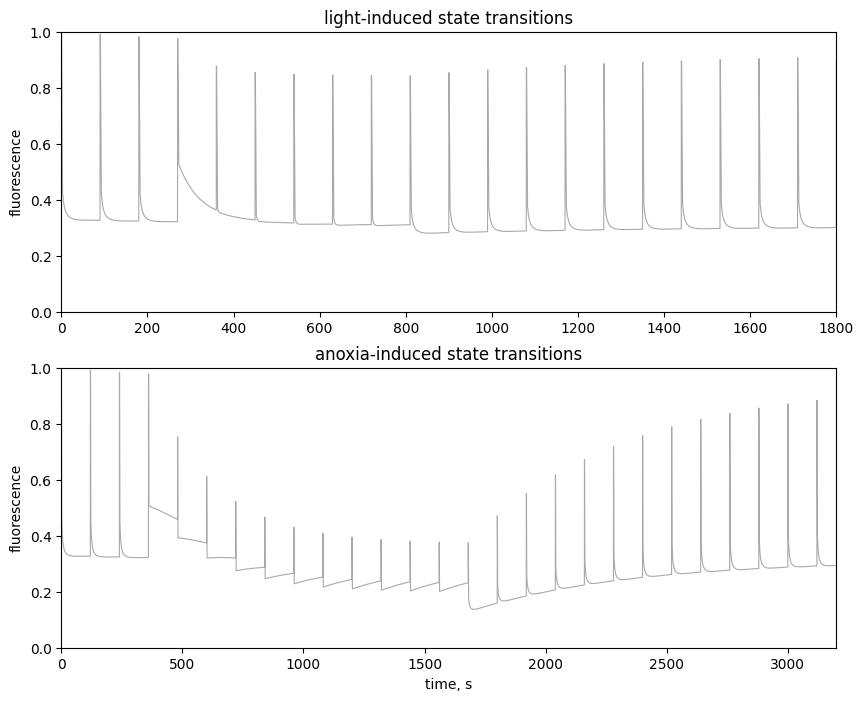

In [3]:
fig, axs = plt.subplots(figsize=(10, 8), nrows=2)

axs[0].plot(res_fig2["normal"].index, res_fig2["normal"]["Fluo"] / res_fig2["normal"]["Fluo"].max(), color="#a7a9ac", lw=0.8, label="Simulation")
axs[1].plot(res_fig2["anoxia"].index, res_fig2["anoxia"]["Fluo"] / res_fig2["anoxia"]["Fluo"].max(), color="#a7a9ac", lw=0.8, label="Simulation")

axs[0].set_xlim(0, 1800)
axs[0].set_xticks(np.linspace(0, 1800, 10))
axs[0].set_title("light-induced state transitions")

axs[1].set_xlim(0, 3200)
axs[1].set_xticks(np.linspace(0, 3000, 7))
axs[1].set_xlabel("time, s")
axs[1].set_title("anoxia-induced state transitions")

for ax in axs:
    ax.set_ylim(0, 1)
    ax.set_yticks(np.linspace(0, 1, 6))
    ax.set_ylabel("fluorescence")

plt.show()

## Figure 3

In [4]:
m = get_ebenhoeh2014()

m.add_parameter(
    name="steady_cross_section",
    value=1.0
)

m.update_derived(
    name="PSII_cross_section",
    fn=constant,
    args=["steady_cross_section"]
)

res_fig3 = scan.steady_state(
    model=m,
    to_scan=cartesian_product({
        "steady_cross_section": np.arange(0, 1, 0.2/4),
        "PPFD": np.arange(0, 500, 100/4)
    }),
    integrator=bdf_integrator
).combined

res_fig3 = res_fig3["Plastoquinone (reduced)"] / m.get_parameter_values()["PQ_tot"]

  0%|          | 0/400 [00:00<?, ?it/s]/home/elouen/Documents/mxl-models/.venv/lib/python3.13/site-packages/scipy/integrate/_ivp/bdf.py:416: RuntimeWarning: invalid value encountered in subtract
  D[order + 2] = d - D[order + 1]
100%|██████████| 400/400 [00:21<00:00, 18.48it/s]


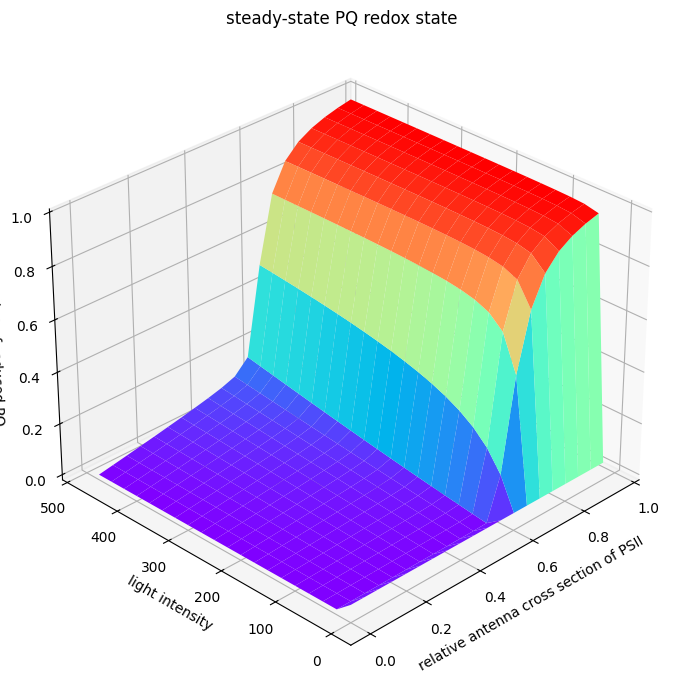

In [10]:
grid_df = res_fig3.unstack()

X, Y = np.meshgrid(grid_df.index, grid_df.columns, indexing="ij")
Z = grid_df.values

fig = plt.figure(figsize=(10, 7))
ax = fig.add_subplot(111, projection="3d")

surf = ax.plot_surface(X, Y, Z, cmap="rainbow", edgecolor="none")
ax.view_init(elev=30, azim=45)
ax.invert_xaxis()
ax.invert_yaxis()

ax.set_xlabel("relative antenna cross section of PSII")
ax.set_ylabel("light intensity")
ax.set_zlabel("fraction of reduced PQ")
ax.set_title("steady-state PQ redox state")

plt.tight_layout()